## FLIGHT RISK

### Exploratory Data Analysis (EDA)

In [35]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv

In [2]:
load_dotenv()
START_YEAR = os.environ.get('START_YEAR')
END_YEAR = os.environ.get('END_YEAR')

columns_mapping = {
    "ICAO Empresa Aérea": "airline_icao",
    "Número Voo": "flight_id",
    "Código Autorização (DI)": "authorization_code",
    "Código Tipo Linha": "flight_type_code",
    "ICAO Aeródromo Origem": "origin_icao",
    "ICAO Aeródromo Destino": "destination_icao",
    "Partida Prevista": "dep_scheduled",
    "Partida Real": "dep_actual",
    "Chegada Prevista": "arr_scheduled",
    "Chegada Real": "arr_actual",
    "Situação Voo": "flight_status",
    "Código Justificativa": "delay_reason_code"
}
datetime_cols = [
    "dep_scheduled",
    "dep_actual",
    "arr_scheduled",
    "arr_actual"
]

In [3]:
data = pd.read_csv(
    f"../.data/vra_{START_YEAR}_to_{END_YEAR}.csv",
    sep=";",
    low_memory=False
)

In [4]:
# Rename cols to convention format
data = data.rename(columns=columns_mapping)

# Convert DateTime columns
data[datetime_cols] = (
    data[datetime_cols].apply(
        lambda col: pd.to_datetime(col, format="ISO8601") \
        .dt.floor("s") \
        .astype("datetime64[ns]")
    )
)

In [5]:
data.head()

,airline_icao,flight_id,authorization_code,flight_type_code,origin_icao,destination_icao,dep_scheduled,dep_actual,arr_scheduled,arr_actual,flight_status,delay_reason_code
0,TAM,3633,0,N,SBRJ,SBGR,2022-01-06 14:20:00,2022-01-06 14:31:00,2022-01-06 15:25:00,2022-01-06 15:29:00,REALIZADO,NaN
1,TAM,3633,0,N,SBRJ,SBGR,2022-01-07 14:20:00,2022-01-07 14:47:00,2022-01-07 15:25:00,2022-01-07 15:42:00,REALIZADO,NaN
2,TAM,3633,0,N,SBRJ,SBGR,2022-01-08 14:20:00,2022-01-08 14:12:00,2022-01-08 15:25:00,2022-01-08 15:12:00,REALIZADO,NaN
3,TAM,3633,0,N,SBRJ,SBGR,2022-01-09 14:20:00,2022-01-09 14:16:00,2022-01-09 15:25:00,2022-01-09 15:15:00,REALIZADO,NaN
4,TAM,3633,0,N,SBRJ,SBGR,2022-01-11 14:20:00,2022-01-11 14:20:00,2022-01-11 15:25:00,2022-01-11 15:15:00,REALIZADO,NaN


#### Data Quality

In [6]:
data.shape

(4190189, 12)

In [7]:
data.dtypes

airline_icao                     str
flight_id                        str
authorization_code               str
flight_type_code                 str
origin_icao                      str
destination_icao                 str
dep_scheduled         datetime64[ns]
dep_actual            datetime64[ns]
arr_scheduled         datetime64[ns]
arr_actual            datetime64[ns]
flight_status                    str
delay_reason_code            float64
dtype: object

In [8]:
# Missing Values

pd.concat([
    data.isna().sum().rename("missing_count"),
    (data.isna().mean() * 100).round(2).rename("missing_pct")
], axis=1).sort_values("missing_pct", ascending=False)

,missing_count,missing_pct
delay_reason_code,4190189,100.00
dep_actual,168186,4.01
arr_actual,168186,4.01
dep_scheduled,136254,3.25
arr_scheduled,136256,3.25
flight_type_code,471,0.01
airline_icao,0,0.00
flight_id,0,0.00
authorization_code,0,0.00
destination_icao,0,0.00


In [9]:
# NOTE: the 'dep_actual' is NA because the flight was cancelled.

data[
    data["dep_actual"].isna()
]["flight_status"].value_counts()

flight_status
CANCELADO        166725
NÃO INFORMADO      1461
Name: count, dtype: int64

In [10]:
# NOTE: the 'arr_actual' is NA because the flight was cancelled.

data[
    data["arr_actual"].isna()
]["flight_status"].value_counts()

flight_status
CANCELADO        166725
NÃO INFORMADO      1461
Name: count, dtype: int64

In [11]:
# Flight status

data["flight_status"].value_counts()

flight_status
REALIZADO        4022003
CANCELADO         166725
NÃO INFORMADO       1461
Name: count, dtype: int64

In [12]:
# Duplicated Values

data.duplicated().sum()

np.int64(21)

In [13]:
# NOTE: only flights that have been carried out should be considered to calculate the delay
# NOTE: use the 'data_delay' df to modeling

data_delay = data.loc[
    data["flight_status"] == "REALIZADO"
].copy()

In [14]:
data_delay.shape

(4022003, 12)

#### Target Analysis

In [15]:
# Arrival delay

data_delay["arr_delay_min"] = (
    data_delay["arr_actual"] - data_delay["arr_scheduled"]
).dt.total_seconds() / 60

In [16]:
# Departure delay
data_delay["dep_delay_min"]= (
    data_delay["dep_actual"] - data_delay["dep_scheduled"]
).dt.total_seconds() / 60

In [17]:
# NOTE: negative values == before scheduled time
# NOTE: the passenger notices the arrive delay, so arr_delay will be the TARGET

data_delay[["dep_delay_min", "arr_delay_min"]]

,dep_delay_min,arr_delay_min
0,11.0,4.0
1,27.0,17.0
2,-8.0,-13.0
3,-4.0,-10.0
4,0.0,-10.0
...,...,...
4190184,11.0,14.0
4190185,35.0,37.0
4190186,24.0,14.0
4190187,4.0,0.0


In [18]:
# Data basic Stats
print(
    (
        f"Mean -> {data_delay["arr_delay_min"].mean()} \n"
        f"Min -> {data_delay["arr_delay_min"].min()} \n"
        f"Max -> {data_delay["arr_delay_min"].max()} \n"
        f"STD -> {data_delay["arr_delay_min"].std()} \n"
    )
)

Mean -> 3.8687102875892685 
Min -> -524907.0 
Max -> 1052686.0 
STD -> 606.234068987051 



In [19]:
data_delay["arr_delay_min"].quantile(
    [0.5, 0.75, 0.9, 0.95, 0.99]
)

0.50     -4.0
0.75      8.0
0.90     28.0
0.95     49.0
0.99    153.0
Name: arr_delay_min, dtype: float64

In [27]:
data_delay["arr_delay_min"].describe(
    percentiles=[0.90, 0.95, 0.99, 0.999]
)

count    3.885750e+06
mean     3.868710e+00
std      6.062341e+02
min     -5.249070e+05
90%      2.800000e+01
95%      4.900000e+01
99%      1.530000e+02
99.9%    7.990000e+02
max      1.052686e+06
Name: arr_delay_min, dtype: float64

In [20]:
data_delay.nsmallest(10, "arr_delay_min")[
    [
        "arr_scheduled",
        "arr_actual",
        "arr_delay_min"
    ]
]

,arr_scheduled,arr_actual,arr_delay_min
1002269,2023-02-12 02:05:00,2022-02-12 13:38:00,-524907.0
3521515,2025-09-15 17:00:00,2025-06-13 23:59:00,-134941.0
1896613,2024-02-04 14:15:00,2024-01-31 13:51:00,-5784.0
1896616,2024-02-03 09:15:00,2024-01-31 09:16:00,-4319.0
2001515,2024-02-11 13:05:00,2024-02-08 13:51:00,-4274.0
2081540,2024-03-31 01:00:00,2024-03-28 02:33:00,-4227.0
2081535,2024-03-31 08:25:00,2024-03-28 10:33:00,-4192.0
2081544,2024-03-31 13:40:00,2024-03-28 16:35:00,-4145.0
3142771,2025-04-26 03:40:00,2025-04-24 01:56:00,-2984.0
2153652,2024-04-27 05:10:00,2024-04-25 03:55:00,-2955.0


In [21]:
data_delay.nlargest(10, "arr_delay_min")[
    [
        "arr_scheduled",
        "arr_actual",
        "arr_delay_min"
    ]
]

,arr_scheduled,arr_actual,arr_delay_min
254905,2022-04-21 05:10:00,2024-04-21 05:56:00,1052686.0
4023215,2026-03-30 00:50:00,2026-04-30 04:24:00,44854.0
628170,2022-10-01 08:40:00,2022-11-01 11:58:00,44838.0
2851448,2025-01-03 14:15:00,2025-02-03 14:00:00,44625.0
345457,2022-06-06 14:20:00,2022-06-13 13:03:00,10003.0
3048066,2025-03-17 14:50:00,2025-03-23 02:46:00,7916.0
3255316,2025-05-08 21:15:00,2025-05-14 09:08:00,7913.0
3636582,2025-10-23 22:50:00,2025-10-29 06:54:00,7684.0
536507,2022-08-25 00:05:00,2022-08-29 21:30:00,7045.0
1930333,2024-01-30 12:55:00,2024-02-03 21:45:00,6290.0


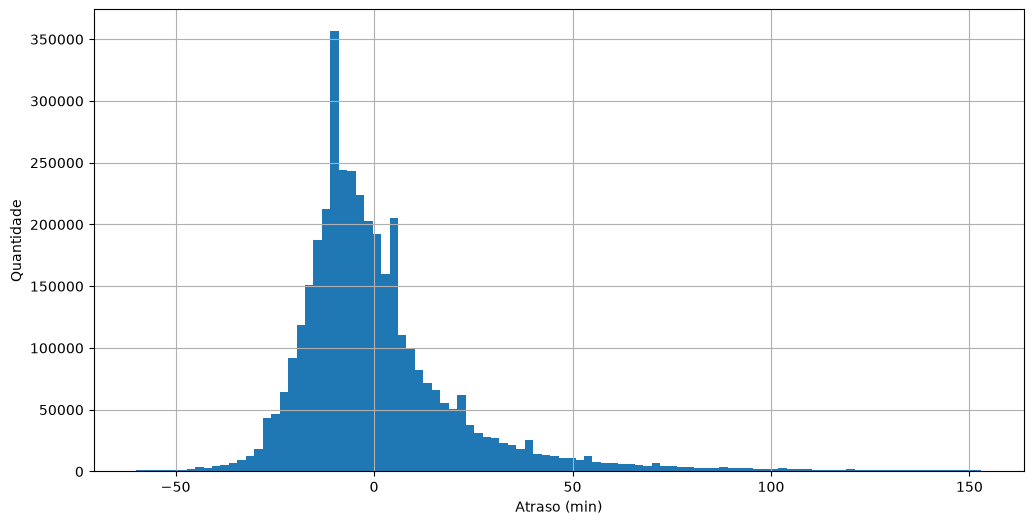

In [ ]:
p99 = data_delay["arr_delay_min"].quantile(0.99)

plt.figure(figsize=(12, 6))

data_delay.loc[
    data_delay["arr_delay_min"].between(-60, p99),
    "arr_delay_min"
].hist(bins=100)

plt.xlabel("Atraso (min)")
plt.ylabel("Quantidade")
plt.show()

<Axes: ylabel='arr_delay_min'>

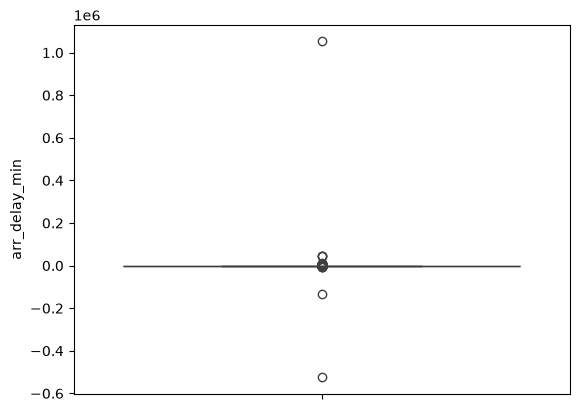

In [37]:
sns.boxplot(data_delay["arr_delay_min"])

In [29]:
# OUTLIERS

for limite in [180, 360, 720, 1440]:
    pct = (
        ~data_delay["arr_delay_min"]
        .between(-180, limite)
    ).mean() * 100

    print(
        f"Limite {limite:4} min -> "
        f"{pct:.4f}% removidos"
    )

Limite  180 min -> 4.2208% removidos
Limite  360 min -> 3.7432% removidos
Limite  720 min -> 3.6083% removidos
Limite 1440 min -> 3.5266% removidos


In [31]:
bins = [
    -np.inf,
    -1440,
    -720,
    -180,
    -60,
    0,
    60,
    180,
    720,
    1440,
    np.inf
]

pd.cut(
    data_delay["arr_delay_min"],
    bins=bins
).value_counts().sort_index()

arr_delay_min
(-inf, -1440.0]          905
(-1440.0, -720.0]       1717
(-720.0, -180.0]        1776
(-180.0, -60.0]         9275
(-60.0, 0.0]         2362353
(0.0, 60.0]          1363858
(60.0, 180.0]         116738
(180.0, 720.0]         24634
(720.0, 1440.0]         3288
(1440.0, inf]           1206
Name: count, dtype: int64

In [ ]:
# NOTE: A distribuição dos atrasos apresentou forte concentração entre -60 e 180 minutos,
# representando aproximadamente 99% dos registros. Foram identificados registros extremos com diferenças
# superiores a vários dias e até anos entre horários programados e realizados,
# indicando problemas de qualidade dos dados ou eventos operacionais excepcionais.
# Para a modelagem foram mantidos apenas voos com atrasos entre -180 e 180 minutos, preservando o comportamento operacional típico
# e reduzindo o impacto de anomalias.

data_model = data_delay[
    data_delay["arr_delay_min"].between(-180, 180)
].copy()

In [33]:
data_model.shape

(3852243, 14)

In [34]:
data_model["arr_delay_min"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
)

count    3.852243e+06
mean     1.442468e+00
std      2.444365e+01
min     -1.800000e+02
25%     -1.200000e+01
50%     -4.000000e+00
75%      8.000000e+00
90%      2.600000e+01
95%      4.400000e+01
99%      1.050000e+02
max      1.800000e+02
Name: arr_delay_min, dtype: float64